In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
# Загружаем датасет о диабете
X, y = load_diabetes(return_X_y=True)
# Инициализируем модель линейной регрессии
regressor = LinearRegression()
# Обучаем модель
regressor.fit(X,y)

## LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# Производим сериализацию обученной модели
import pickle
model = pickle.dumps(regressor)
print(type(model))
print(type(regressor))

<class 'bytes'>
<class 'sklearn.linear_model._base.LinearRegression'>


In [32]:
# Производим десериализацию
regressor_from_bytes = pickle.loads(model)
regressor_from_bytes

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# Производим сериализацию и записываем результат в файл формата pkl
with open('myfile.pkl', 'wb') as output:
    pickle.dump(regressor, output)

In [34]:
# Производим десериализацию и извлекаем модель из файла формата pkl
with open('myfile.pkl', 'rb') as pkl_file:
    regressor_from_file = pickle.load(pkl_file)
    
regressor_from_file
## LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
# Проверяем, что все элементы массивов предсказаний совпадают между собой
all(regressor.predict(X) == regressor_from_bytes.predict(X))
all(regressor.predict(X) == regressor_from_file.predict(X))

True

In [36]:
# my_lambda = lambda x: x*2
# with open('my_lambda.pkl', 'wb') as output:
#     pickle.dump(my_lambda, output)
    
##"PicklingError: Can't pickle <function <lambda>"

In [37]:
import pickle

from sklearn.linear_model import LinearRegression

from sklearn.datasets import load_diabetes

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.preprocessing import MinMaxScaler

from sklearn.pipeline import Pipeline

# Загружаем датасет о диабете
X, y = load_diabetes(return_X_y=True)

# Создаём пайплайн, который включает нормализацию, отбор признаков и обучение модели
pipe = Pipeline([  
  ('Scaling', MinMaxScaler()),
  ('FeatureSelection', SelectKBest(f_regression, k=5)),
  ('Linear', LinearRegression())
  ])

# Обучаем пайплайн
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaling', ...), ('FeatureSelection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...001D93803F2E0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [38]:
# Сериализуем pipeline и записываем результат в файл
with open('my_pipeline.pkl', 'wb') as output:
    pickle.dump(pipe, output)

In [39]:
# Десериализуем pipeline из файла
with open('my_pipeline.pkl', 'rb') as pkl_file:
    loaded_pipe = pickle.load(pkl_file)

In [40]:
# Сравниваем предсказания исходного и восстановленного пайплайнов
print(all(pipe.predict(X) == loaded_pipe.predict(X)))

## True

True


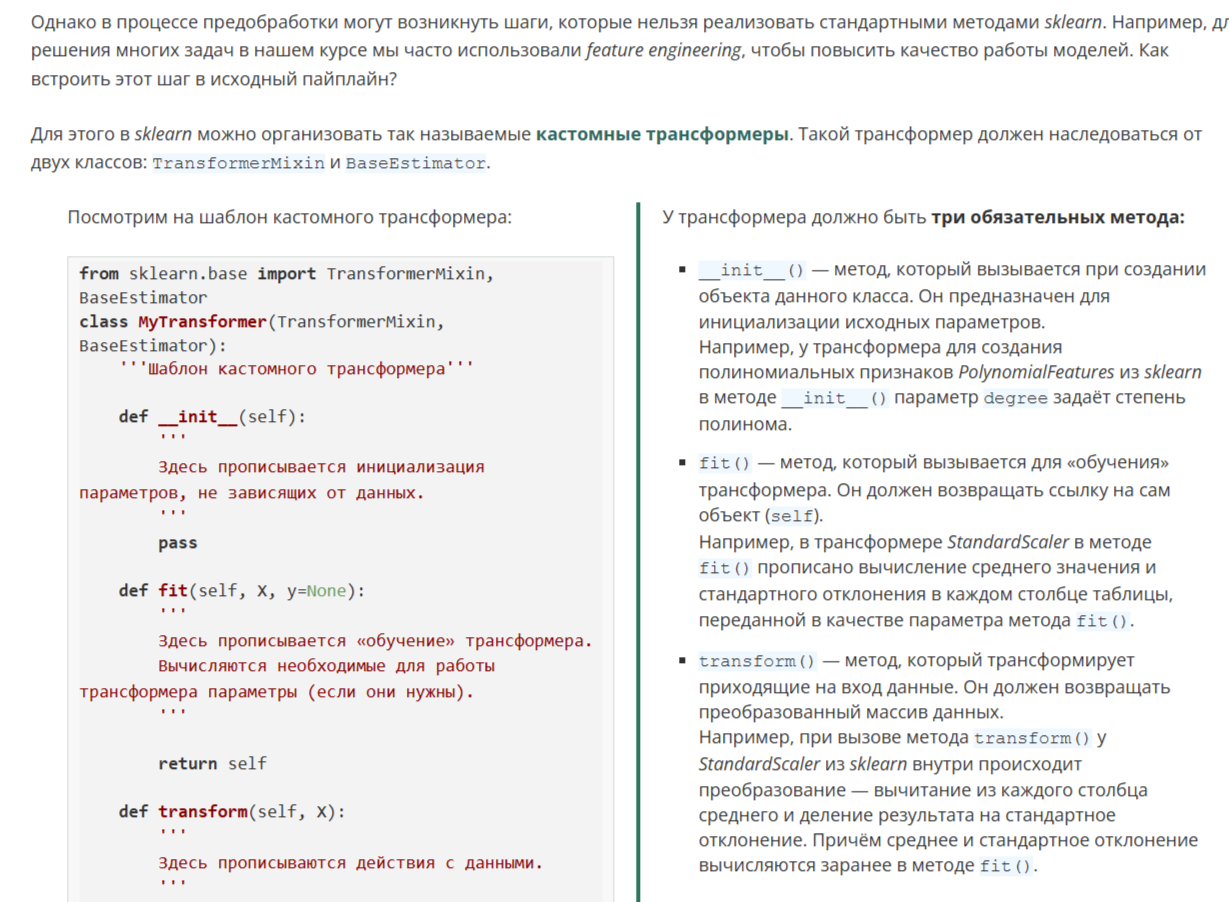

In [41]:
from sklearn.base import TransformerMixin, BaseEstimator
class MyTransformer(TransformerMixin, BaseEstimator):
    '''Шаблон кастомного трансформера'''
 
    def __init__(self):
        '''
        Здесь прописывается инициализация параметров, не зависящих от данных.
        '''
        pass
 
    def fit(self, X, y=None):
        '''
        Здесь прописывается «обучение» трансформера.
        Вычисляются необходимые для работы трансформера параметры (если они нужны).
        '''

        return self
 
    def transform(self, X):
        '''
        Здесь прописываются действия с данными.
        '''
        return X

In [43]:
class MyTransformer(TransformerMixin, BaseEstimator):
    '''Шаблон кастомного трансформера'''


    def __init__(self):
        '''Здесь прописывается инициализация параметров, не зависящих от данных.'''
        pass


    def fit(self, X, y=None):
        '''
        Здесь прописывается «обучение» трансформера.
        Вычисляются необходимые для работы трансформера параметры (если они нужны).
        '''
        return self


    def transform(self, X):
        '''Здесь прописываются действия с данными.'''
        # Создаём новый столбец как произведение первых трёх
        new_column = X[:, 0] * X[:, 1] * X[:, 2]
        # Для добавления столбца в массив нужно изменить его размер на (n_rows, 1)
        new_column = new_column.reshape(X.shape[0], 1)
        # Добавляем столбец в матрицу измерений
        X = np.append(X, new_column, axis=1)
        return X

In [44]:
# Инициализируем объект класса MyTransformer (вызывается метод __init__)
custom_transformer = MyTransformer()
# Чисто формально вызываем метод fit, но у нас он ничего не делает
custom_transformer.fit(X)
# Трансформируем исходные данные (вызывается метод transform)
X_transformed = custom_transformer.transform(X)
print('Shape before transform: {}'.format(X.shape))
print('Shape after transform: {}'.format(X_transformed.shape))

## Shape before transform: (442, 10)
## Shape after transform: (442, 11)

Shape before transform: (442, 10)
Shape after transform: (442, 11)


In [45]:
pipe = Pipeline([  
  ('FeatureEngineering', MyTransformer()),
  ('Scaling', MinMaxScaler()),
  ('FeatureSelection', SelectKBest(f_regression, k=5)),
  ('Linear', LinearRegression())
  ])

# Обучаем пайплайн
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FeatureEngineering', ...), ('Scaling', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...001D93803F2E0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [46]:
# Сериализуем pipeline и записываем результат в файл
with open('my_new_pipeline.pkl', 'wb') as output:
    pickle.dump(pipe, output)

In [49]:
features = np.array([[ 0.00538306, -0.04464164,  0.05954058, -0.05616605,  
                      0.02457414, 0.05286081, -0.04340085,  0.05091436, 
                      -0.00421986, -0.03007245]])

with open('my_new_pipeline.pkl', 'rb') as pipe:
    loaded_new_pipe = pickle.load(pipe)
loaded_new_pipe.predict(features)

array([173.01985747])

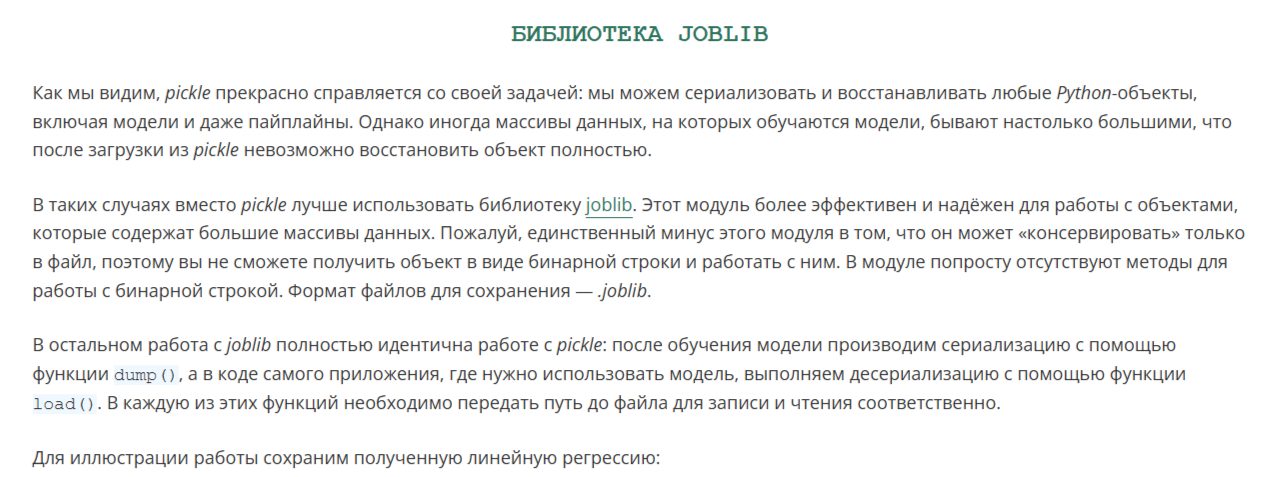

In [50]:
import joblib

# Загружаем датасет о диабете
X, y = load_diabetes(return_X_y=True)
# Обучаем модель линейной регрессии
regressor = LinearRegression()
regressor.fit(X, y)
# Производим сериализацию и сохраняем результат в файл формата .joblib
joblib.dump(regressor, 'regr.joblib')

## ['regr.joblib']

['regr.joblib']

In [51]:
# Десериализуем модель из файла
clf_from_jobliv = joblib.load('regr.joblib') 
# Сравниваем предсказания
all(regressor.predict(X) == clf_from_jobliv.predict(X))

## True

True

In [53]:
# Практика
with open('model.pkl', 'rb') as pkl_model:
    load_model = pickle.load(pkl_model)

secret word: skillfactory
how is this possible? answer is here: https://youtu.be/xm-A-h9QkXg


In [54]:
print(type(load_model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [58]:
val = np.array([1, 1, 1, 0.661212487096872]).reshape(1, -1)
load_model.predict(val)

array([0.666])

In [62]:
dict_model = {'a' : load_model.a, 'b' : load_model.b}
with open('dict_model.pkl', 'wb') as dict_m:
    pickle.dump(dict_model, dict_m)

In [63]:
!python hw1_check_ol.py dict_model.pkl

python: can't open file 'c:\\Users\\user\\Desktop\\Skilfactory\\DS_Prod\\hw1_check_ol.py': [Errno 2] No such file or directory


In [64]:
from nyoka import skl_to_pmml
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)
cols = load_diabetes()['feature_names']

scaler = MinMaxScaler()
pipe = Pipeline([  
            ('Scaling', MinMaxScaler()),
            ('Linear', LinearRegression())
        ])
# Обучение пайплайна, включающего линейную модель и нормализацию признаков
pipe.fit(X, y)
# Сохраним пайплайн в формате pmml в файл pipeline.pmml
skl_to_pmml(pipeline=pipe, col_names=cols, pmml_f_name="pipeline.pmml")